# WorkShop - 4
# Coin Detection using OpenCV in Python

## NAME : Vignesh S
## REG NO : 212224110061

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

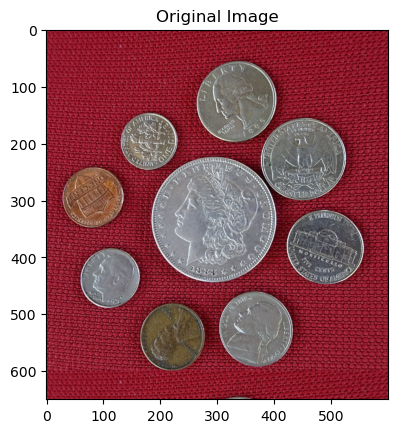

In [6]:
image = cv2.imread('CoinsA.png')
imageCopy = image.copy()
plt.imshow(image[:,:,::-1]);
plt.title("Original Image")
plt.show()

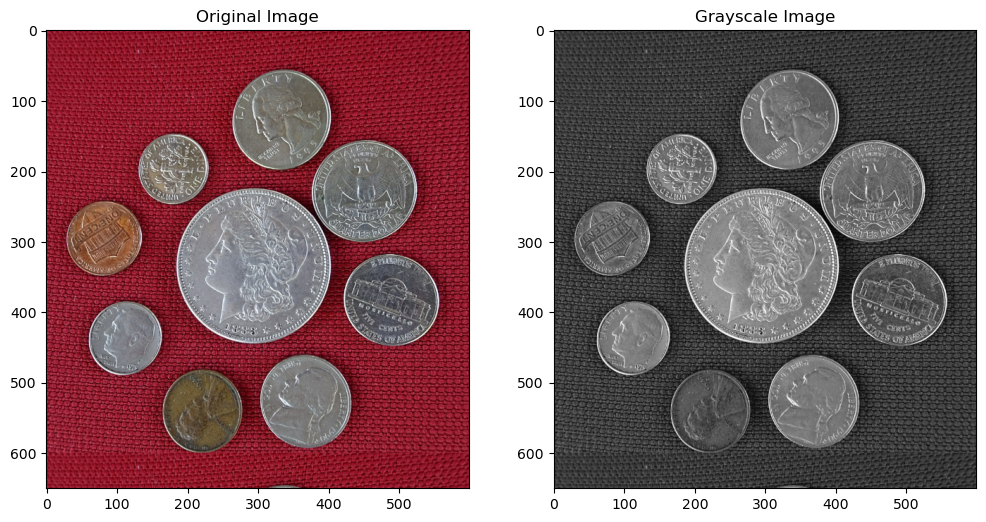

<Figure size 2000x1200 with 0 Axes>

<Figure size 2000x1200 with 0 Axes>

In [10]:
imageGray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
imageB, imageG, imageR = cv2.split(image)
plt.figure(figsize=(12,12))
plt.subplot(121);plt.imshow(image[:,:,::-1]);plt.title("Original Image")
plt.subplot(122); plt.imshow(imageGray,cmap='gray');plt.title("Grayscale Image"); plt.show()
plt.figure(figsize=(20,12))

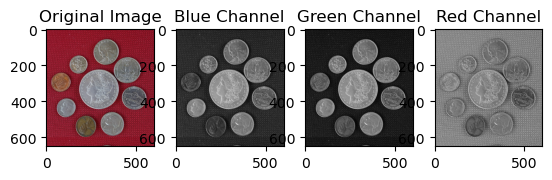

In [11]:
plt.subplot(141);plt.imshow(image[:,:,::-1]);plt.title("Original Image")
plt.subplot(142);plt.imshow(imageB,cmap='gray');plt.title("Blue Channel")
plt.subplot(143);plt.imshow(imageG,cmap='gray');plt.title("Green Channel")
plt.subplot(144);plt.imshow(imageR,cmap='gray');plt.title("Red Channel");
plt.show()

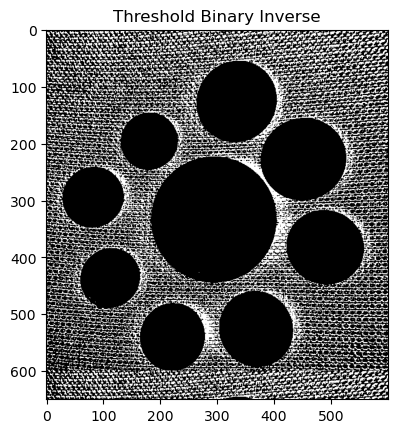

In [12]:
thresh =20
maxValue = 255
th, dst_bin_inv = cv2.threshold(imageG, thresh, maxValue, cv2.THRESH_BINARY_INV)
plt.imshow(dst_bin_inv, cmap='gray', vmin=0, vmax=255)
plt.title("Threshold Binary Inverse");

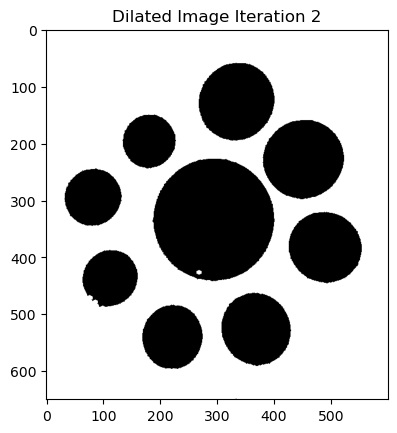

In [13]:
kSize = (5,5)
kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kSize)
imageDilated2 = cv2.dilate(dst_bin_inv, kernel2, iterations=2)
plt.imshow(imageDilated2,cmap='gray')
plt.title('Dilated Image Iteration 2')
plt.show()

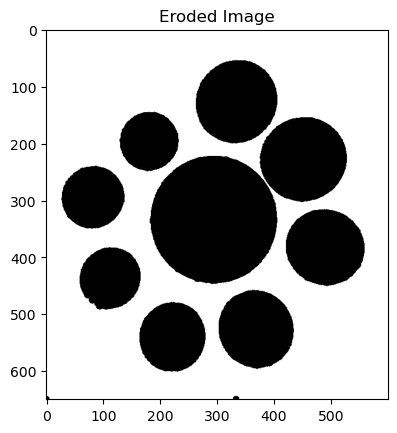

In [14]:
kSize = (11,11)
kernel1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kSize)
imageEroded = cv2.erode(imageDilated2, kernel1)
plt.imshow(imageEroded,cmap='gray')
plt.title("Eroded Image")
plt.show()

In [15]:
# Set up the SimpleBlobdetector with default parameters.
params = cv2.SimpleBlobDetector_Params()

params.blobColor = 0

params.minDistBetweenBlobs = 2


In [16]:
# Filter by Area.
params.filterByArea = False

# Filter by Circularity
params.filterByCircularity = True
params.minCircularity = 0.8

# Filter by Convexity
params.filterByConvexity = True
params.minConvexity = 0.8

# Filter by Inertia
params.filterByInertia =True
params.minInertiaRatio = 0.8

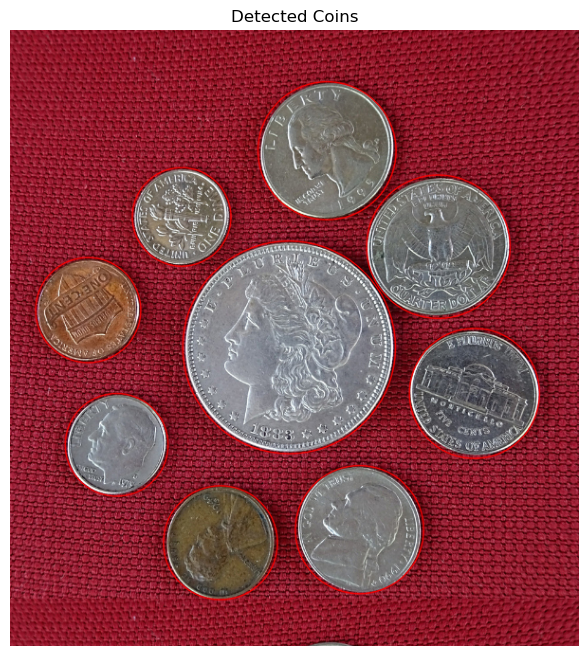

In [17]:
# Create detector
detector = cv2.SimpleBlobDetector_create(params)

# Detect blobs
keypoints = detector.detect(imageEroded)

# Draw detected coins
imageWithKeypoints = cv2.drawKeypoints(
    image,
    keypoints,
    np.array([]),
    (0, 0, 255),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Display result
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(imageWithKeypoints, cv2.COLOR_BGR2RGB))
plt.title("Detected Coins")
plt.axis("off")
plt.show()
